# 01 - Cleaning and Target Definition

## Cel notebooka
Celem jest wykonanie cleaningu operacyjnego danych OHLCV, zdefiniowanie targetu klasyfikacyjnego (`sell/hold/buy`) i zapisanie artefakt?w do kolejnych etap?w pipeline'u.

## Wej?cie
- `data/raw/ethusdt_1h.csv`

## Wyj?cie
- `data/interim/eth_clean.csv`
- `data/interim/eth_labeled.csv`
- `reports/cleaning_target_metadata.json`


In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [31]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../../data/clean/'
LABELED_PATH = '../../data/labeled/'


raw_data = pd.read_csv(DATA_PATH)
assert not raw_data.empty, "DataFrame is empty"

## 2. Cleaning operacyjny
Reguly:
- konwersja `timestamp` do UTC datetime,
- sortowanie chronologiczne,
- usuniecie duplikatow po `timestamp`,
- konwersja kolumn numerycznych,
- usuniecie rekordow niespojnych OHLCV.


In [32]:
try:
    from stylin import InfoDisplayStyler
    styler = InfoDisplayStyler()
except Exception:
    class _FallbackStyler:
        def style_me(self, obj, title=None):
            if title:
                print(f"\n=== {title} ===")
            display(obj)

        def show_line(self, value, title=None):
            if title:
                print(f"{title}: {value}")
            else:
                print(value)

        def show_meta(self, obj):
            print("shape:", getattr(obj, 'shape', None))
            display(obj.head(3) if hasattr(obj, 'head') else obj)

    styler = _FallbackStyler()


In [33]:
def clean_ohlcv(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    stats: dict[str, int] = {}
    work = df.copy()

    stats["rows_initial"] = int(len(work))

    work["timestamp"] = pd.to_datetime(work["timestamp"], utc=True, errors="coerce")
    stats["invalid_timestamp_rows"] = int(work["timestamp"].isna().sum())
    work = work.dropna(subset=["timestamp"]).copy()

    work = work.sort_values("timestamp").copy()

    duplicated_ts = int(work["timestamp"].duplicated().sum())
    stats["duplicated_timestamps"] = duplicated_ts
    work = work.drop_duplicates(subset=["timestamp"], keep="first").copy()

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]
    for col in numeric_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    stats["nan_numeric_before_drop"] = int(work[numeric_cols].isna().sum().sum())
    work = work.dropna(subset=numeric_cols).copy()

    invalid_price_nonpositive = (
        (work["open"] <= 0)
        | (work["high"] <= 0)
        | (work["low"] <= 0)
        | (work["close"] <= 0)
    )
    invalid_high = work["high"] < work[["open", "close"]].max(axis=1)
    invalid_low = work["low"] > work[["open", "close"]].min(axis=1)
    negative_volume = work["volume"] < 0

    invalid_any = invalid_price_nonpositive | invalid_high | invalid_low | negative_volume

    stats["invalid_price_nonpositive"] = int(invalid_price_nonpositive.sum())
    stats["invalid_high"] = int(invalid_high.sum())
    stats["invalid_low"] = int(invalid_low.sum())
    stats["negative_volume"] = int(negative_volume.sum())
    stats["rows_removed_integrity"] = int(invalid_any.sum())

    work = work.loc[~invalid_any].copy()

    work = work.set_index("timestamp")
    work = work.sort_index()

    stats["rows_final"] = int(len(work))
    return work, stats


clean_df, cleaning_stats = clean_ohlcv(raw_data)

styler.style_me(pd.DataFrame([cleaning_stats]), title="Cleaning stats")
styler.style_me(clean_df.head(5), title="Clean head")


,rows_initial,invalid_timestamp_rows,duplicated_timestamps,nan_numeric_before_drop,invalid_price_nonpositive,invalid_high,invalid_low,negative_volume,rows_removed_integrity,rows_final
0,46258,0,0,0,0,0,0,0,0,46258


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
timestamp,,,,,,,,,
2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215
2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503
2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084
2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875
2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872


## 3. Polityka luk czasowych
Nie imputujemy cen. Luki sa raportowane i pozostaja jawne; ich wplyw bedzie kontrolowany na etapie feature engineeringu (lagi/rollingi + `dropna`).


In [34]:
full_idx = pd.date_range(clean_df.index.min(), clean_df.index.max(), freq="h", tz="UTC")
missing_hours = full_idx.difference(clean_df.index)

delta = clean_df.index.to_series().diff()
expected = pd.Timedelta(hours=1)
non_1h_intervals = int((delta.notna() & (delta != expected)).sum())

gap_report = pd.DataFrame(
    {
        "rows_clean": [len(clean_df)],
        "missing_hours_count": [int(len(missing_hours))],
        "non_1h_intervals": [non_1h_intervals],
        "min_timestamp": [clean_df.index.min()],
        "max_timestamp": [clean_df.index.max()],
    }
)
styler.style_me(gap_report, title="Gap report")
styler.style_me(pd.DataFrame({"missing_hours": missing_hours[:20]}), title="Missing hour examples")


,rows_clean,missing_hours_count,non_1h_intervals,min_timestamp,max_timestamp
0,46258,14,7,2021-01-01 00:00:00+00:00,2026-04-12 23:00:00+00:00


,missing_hours
0,2021-02-11 04:00:00+00:00
1,2021-03-06 02:00:00+00:00
2,2021-04-20 02:00:00+00:00
3,2021-04-20 03:00:00+00:00
4,2021-04-25 05:00:00+00:00
5,2021-04-25 06:00:00+00:00
6,2021-04-25 07:00:00+00:00
7,2021-08-13 02:00:00+00:00
8,2021-08-13 03:00:00+00:00
9,2021-08-13 04:00:00+00:00


## 4. Definicja targetu (3 klasy)
- `future_return = close(t+h) / close(t) - 1`
- `0 = sell` gdy `future_return < -threshold`
- `1 = hold` gdy `-threshold <= future_return <= threshold`
- `2 = buy` gdy `future_return > threshold`


In [35]:
HORIZON = 6
THRESHOLD = 0.0075


def make_multiclass_target(
    df: pd.DataFrame,
    horizon: int = 6,
    threshold: float = 0.0075,
    close_col: str = "close",
) -> pd.DataFrame:
    work = df.copy()
    work["future_return"] = work[close_col].shift(-horizon) / work[close_col] - 1.0

    work["target"] = 1
    work.loc[work["future_return"] < -threshold, "target"] = 0
    work.loc[work["future_return"] > threshold, "target"] = 2

    # Ostatnie rekordy nie maja etykiety (brak przyszlej ceny).
    work = work.iloc[:-horizon].copy()
    return work


labeled_df = make_multiclass_target(clean_df, horizon=HORIZON, threshold=THRESHOLD)

styler.show_line(labeled_df.shape, title="labeled_df shape")
styler.style_me(labeled_df[["close", "future_return", "target"]].head(10), title="Target preview")


,close,future_return,target
timestamp,,,
2021-01-01 00:00:00+00:00,734.070000,0.008037,2
2021-01-01 01:00:00+00:00,748.280000,-0.014567,0
2021-01-01 02:00:00+00:00,744.060000,-0.018802,0
2021-01-01 03:00:00+00:00,744.820000,-0.014957,0
2021-01-01 04:00:00+00:00,742.290000,-0.007383,1
2021-01-01 05:00:00+00:00,740.650000,-0.002430,1
2021-01-01 06:00:00+00:00,739.970000,-0.009163,0
2021-01-01 07:00:00+00:00,737.380000,0.003662,1
2021-01-01 08:00:00+00:00,730.070000,0.010862,2


## 5. Rozklad klas i histogram `future_return`


,count,ratio
target,,
0,11808,0.255300
1,21743,0.470100
2,12701,0.274600


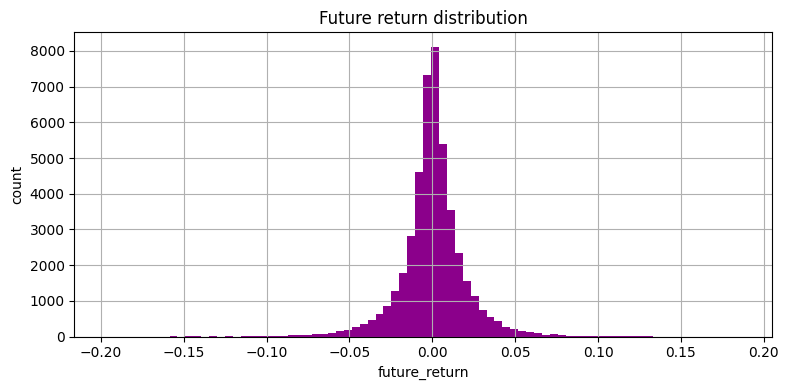

In [36]:
class_counts = labeled_df["target"].value_counts().sort_index()
class_ratio = (class_counts / len(labeled_df)).round(4)

class_report = pd.DataFrame(
    {
        "count": class_counts,
        "ratio": class_ratio,
    }
)
styler.style_me(class_report, title="Class distribution")

plt.figure(figsize=(8, 4))
labeled_df["future_return"].hist(bins=80, color='darkmagenta')
plt.title("Future return distribution")
plt.xlabel("future_return")
plt.ylabel("count")
plt.tight_layout()
plt.show()


6. zapis danych

In [37]:
os.makedirs(CLEAN_PATH, exist_ok=True)
os.makedirs(LABELED_PATH, exist_ok=True)

CLEAN_FILE = CLEAN_PATH + 'eth_clean.csv'
LABELED_FILE = LABELED_PATH + 'eth_labeled.csv'

clean_df.reset_index().to_csv(CLEAN_FILE, index=False)
labeled_df.reset_index().to_csv(LABELED_FILE, index=False)

print("Saved:", CLEAN_FILE)
print("Saved:", LABELED_FILE)

Saved: ../../data/clean/eth_clean.csv
Saved: ../../data/labeled/eth_labeled.csv


## 7. Wnioski koncowe (uzupelnij po uruchomieniu)
- Jakie rekordy usunieto w cleaningu i dlaczego?
- Czy dane sa gotowe do splitu czasowego?
- Czy rozklad klas sugeruje potrzebe wazenia klas?



Wnioski po cleaningu danych
Po zastosowaniu reguł cleaningu (konwersja typów, sortowanie czasu, usunięcie potencjalnie błędnych rekordów OHLCV) zbiór zachował 46 258 rekordów. Nie wykryto naruszeń integralności świec ani rekordów wymagających odrzucenia na tym etapie, więc dane wejściowe są wysokiej jakości i nadają się do dalszego modelowania.

Wnioski dot. osi czasu
Dane są uporządkowane chronologicznie, ale występują punktowe luki czasowe: 7 interwałów nie-1h oraz łącznie 14 brakujących godzin w pełnym zakresie czasowym. Skala problemu jest mała, ale należy ją uwzględnić przy feature engineeringu opartym o lagi i rollingi (żeby nie zaburzyć interpretacji „kroku 1h”).

Wnioski po definicji targetu
Dla parametrów horizon=6 i threshold=0.0075 uzyskano 46 252 rekordy z etykietą (usunięto końcowe 6 obserwacji bez przyszłej ceny). Rozkład klas:

sell (0): 11 808 (25.53%)
hold (1): 21 743 (47.01%)
buy (2): 12 701 (27.46%)
Target jest sensownie zdefiniowany i umiarkowanie niezbalansowany (dominacja klasy hold), co uzasadnia użycie ważenia klas na etapie treningu.

Wniosek końcowy notebooka 01
Notebook poprawnie realizuje etap przygotowania danych pod klasyfikację wieloklasową: cleaning, analiza luk czasowych i etykietowanie zostały wykonane spójni